## Problem 1 

In [1]:
from solver_mc import MaxCutSolver

In [2]:
solver = MaxCutSolver('G22.txt')
best_w, best_s = solver.solve_simulated_annealing()

final_w, final_s = solver.local_search(best_s)

print(f"Final Max-Cut Weight: {final_w}")

Iteration 0: Best Weight = 9919, Temp = 99.9500
Iteration 5000: Best Weight = 10459, Temp = 8.1993
Iteration 10000: Best Weight = 12042, Temp = 0.6726
Iteration 15000: Best Weight = 12647, Temp = 0.0552
Iteration 20000: Best Weight = 12785, Temp = 22.6424
Iteration 25000: Best Weight = 12785, Temp = 1.8574
Iteration 30000: Best Weight = 12785, Temp = 0.1524
Iteration 35000: Best Weight = 12785, Temp = 0.0125
Iteration 40000: Best Weight = 12785, Temp = 5.1292
Iteration 45000: Best Weight = 12785, Temp = 0.4208
Final Max-Cut Weight: 12848


## Problem 2

In [3]:
# DATA Generation

import numpy as np
import matplotlib.pyplot as plt

def generate_data(num_customers=20):
    np.random.seed(42)
    # Depot is at (50, 50)
    locations = np.random.randint(0, 100, size=(num_customers + 1, 2))
    locations[0] = [50, 50] 
    
    # Demands (Depot has 0)
    demands = [0] + list(np.random.randint(5, 20, size=num_customers))
    
    # Time Windows [start, end]
    # Assume travel speed is 1 unit per 1 minute. 
    # Max time 500 mins.
    time_windows = [(0, 1000)] # Depot
    for i in range(num_customers):
        start = np.random.randint(0, 400)
        duration = np.random.randint(60, 180) # 1-3 hour window
        time_windows.append((start, start + duration))
        
    # Vehicle info
    data = {
        'locations': locations,
        'num_locations': num_customers + 1,
        'demands': demands,
        'time_windows': time_windows,
        'num_vehicles': 4,
        'vehicle_capacity': 60,
        'depot': 0,
        'distance_matrix': None
    }
    
    # Calculate Euclidean distance matrix
    dist_matrix = np.zeros((data['num_locations'], data['num_locations']))
    for i in range(data['num_locations']):
        for j in range(data['num_locations']):
            dist_matrix[i][j] = np.linalg.norm(locations[i] - locations[j])
    data['distance_matrix'] = dist_matrix.astype(int)
    
    return data

data = generate_data()
print("Data Generated for 20 Customers.")

Data Generated for 20 Customers.


In [4]:
data

{'locations': array([[50, 50],
        [14, 71],
        [60, 20],
        [82, 86],
        [74, 74],
        [87, 99],
        [23,  2],
        [21, 52],
        [ 1, 87],
        [29, 37],
        [ 1, 63],
        [59, 20],
        [32, 75],
        [57, 21],
        [88, 48],
        [90, 58],
        [41, 91],
        [59, 79],
        [14, 61],
        [61, 46],
        [61, 50]], dtype=int32),
 'num_locations': 21,
 'demands': [0,
  np.int32(16),
  np.int32(11),
  np.int32(8),
  np.int32(13),
  np.int32(7),
  np.int32(9),
  np.int32(7),
  np.int32(11),
  np.int32(9),
  np.int32(13),
  np.int32(11),
  np.int32(6),
  np.int32(8),
  np.int32(13),
  np.int32(16),
  np.int32(18),
  np.int32(6),
  np.int32(14),
  np.int32(13),
  np.int32(14)],
 'time_windows': [(0, 1000),
  (52, 113),
  (339, 490),
  (366, 485),
  (263, 369),
  (34, 171),
  (80, 175),
  (49, 212),
  (387, 448),
  (389, 502),
  (105, 168),
  (309, 461),
  (190, 267),
  (217, 320),
  (161, 294),
  (269, 423),
  (303, 

In [5]:
# Heuristic Solution using OR Tools

import time
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp

def solve_ortools(data):
    manager = pywrapcp.RoutingIndexManager(data['num_locations'], data['num_vehicles'], data['depot'])
    routing = pywrapcp.RoutingModel(manager)

    # 1. Distance Callback
    def distance_callback(from_index, to_index):
        return data['distance_matrix'][manager.IndexToNode(from_index)][manager.IndexToNode(to_index)]
    
    transit_callback_index = routing.RegisterTransitCallback(distance_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    # 2. Capacity Constraint
    def demand_callback(from_index):
        return data['demands'][manager.IndexToNode(from_index)]
    
    demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)
    routing.AddDimensionWithVehicleCapacity(demand_callback_index, 0, [data['vehicle_capacity']] * data['num_vehicles'], True, 'Capacity')

    # 3. Time Window Constraint
    routing.AddDimension(transit_callback_index, 1000, 1000, False, 'Time')
    time_dimension = routing.GetDimensionOrDie('Time')
    for location_idx, (start, end) in enumerate(data['time_windows']):
        index = manager.NodeToIndex(location_idx)
        time_dimension.CumulVar(index).SetRange(start, end)

    # Search parameters
    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC

    solution = routing.SolveWithParameters(search_parameters)
    return manager, routing, solution
start_time = time.time()
manager, routing, solution = solve_ortools(data)
end_time = time.time()
if solution:
    print("OR-Tools found a solution!")
    print(f"Solver Status: {routing.status()}")
    print(f"OR-Tools Objective: {solution.ObjectiveValue()}")
    print(f"OR-Tools Execution Time: {end_time - start_time:.4f} seconds")

OR-Tools found a solution!
Solver Status: 1
OR-Tools Objective: 671
OR-Tools Execution Time: 0.3102 seconds


In [6]:
# # This cell is commented because you need either GLPK or CBC executable files to run this. 
# # If not present on local system one can use the Next cell using Gurobi.


# from pyomo.environ import *

# def solve_pyomo(data):
#     model = ConcreteModel()
    
#     # Sets
#     N = range(data['num_locations'])
#     V = range(data['num_vehicles'])
    
#     # Variables
#     model.x = Var(N, N, V, domain=Binary)
#     model.t = Var(N, V, domain=NonNegativeReals)
    
#     # Objective: Minimize total distance
#     model.obj = Objective(expr=sum(data['distance_matrix'][i][j] * model.x[i,j,v] 
#                                    for i in N for j in N for v in V), sense=minimize)
    
#     # 1. Each customer visited exactly once
#     model.visit_cust = ConstraintList()
#     for j in range(1, data['num_locations']):
#         model.visit_cust.add(sum(model.x[i,j,v] for i in N for v in V if i != j) == 1)
        
#     # 2. Depot flow: vehicle starts and ends at depot
#     model.depot_flow = ConstraintList()
#     for v in V:
#         model.depot_flow.add(sum(model.x[0, j, v] for j in range(1, data['num_locations'])) <= 1)
#         model.depot_flow.add(sum(model.x[i, 0, v] for i in range(1, data['num_locations'])) == 
#                              sum(model.x[0, j, v] for j in range(1, data['num_locations'])))
        
#     # 3. Flow conservation at each node
#     for v in V:
#         for j in N:
#             model.add_component(f"flow_{j}_{v}", 
#                 Constraint(expr=sum(model.x[i,j,v] for i in N if i != j) == 
#                                 sum(model.x[j,k,v] for k in N if k != j)))

#     # 4. Capacity Constraints
#     for v in V:
#         model.add_component(f"cap_{v}", 
#             Constraint(expr=sum(data['demands'][j] * model.x[i,j,v] 
#                                for i in N for j in range(1, data['num_locations']) if i != j) <= data['vehicle_capacity']))

#     # 5. Time Windows & Subtour Elimination (Big M)
#     M = 2000 # Large constant
#     for v in V:
#         for i in N:
#             for j in range(1, data['num_locations']):
#                 if i != j:
#                     # Arrival at j must be after arrival at i + travel time
#                     model.add_component(f"time_{i}_{j}_{v}", 
#                         Constraint(expr=model.t[i,v] + data['distance_matrix'][i][j] <= 
#                                    model.t[j,v] + M * (1 - model.x[i,j,v])))
            
#             # Arrival time within [start, end]
#             model.add_component(f"tw_start_{i}_{v}", Constraint(expr=model.t[i,v] >= data['time_windows'][i][0]))
#             model.add_component(f"tw_end_{i}_{v}", Constraint(expr=model.t[i,v] <= data['time_windows'][i][1]))

#     # Solve
#     # solver = SolverFactory('glpk', executable="C:/glpk-4.65/w64/glpsol.exe")
#     # solver = SolverFactory('cbc', executable="C:/cbc/bin/cbc.exe")
#     # solver = SolverFactory('glpk', executable='/path/to/glpsol')
#     # solver = SolverFactory('cbc', executable='C:/path/to/cbc.exe')
#     results = solver.solve(model)
#     return model
# model_pyo = solve_pyomo(data)

In [7]:
import pyomo.environ as pyo

def solve_vrptw_gurobi(data):
    model = pyo.ConcreteModel()
    
    # Sets
    N = range(data['num_locations'])
    V = range(data['num_vehicles'])
    
    # Variables
    model.x = pyo.Var(N, N, V, domain=pyo.Binary) # Travel from i to j with vehicle v
    model.t = pyo.Var(N, V, domain=pyo.NonNegativeReals) # Arrival time
    
    # Objective: Minimize Total Distance
    model.obj = pyo.Objective(
        expr=sum(data['distance_matrix'][i][j] * model.x[i,j,v] 
                 for i in N for j in N for v in V if i != j), 
        sense=pyo.minimize
    )
    
    # 1. Flow Conservation: Every customer j is visited exactly once
    model.visit = pyo.ConstraintList()
    for j in range(1, data['num_locations']):
        model.visit.add(sum(model.x[i,j,v] for i in N for v in V if i != j) == 1)
        
    # 2. Vehicle starts and ends at Depot (0)
    model.depot_start = pyo.ConstraintList()
    for v in V:
        model.depot_start.add(sum(model.x[0, j, v] for j in range(1, data['num_locations'])) <= 1)
        
    # 3. Continuity: Inflow = Outflow at every node for every vehicle
    model.flow = pyo.ConstraintList()
    for v in V:
        for j in N:
            model.flow.add(sum(model.x[i,j,v] for i in N if i != j) == 
                           sum(model.x[j,k,v] for k in N if k != j))

    # 4. Capacity Constraints
    model.capacity = pyo.ConstraintList()
    for v in V:
        model.capacity.add(sum(data['demands'][j] * model.x[i,j,v] 
                               for i in N for j in range(1, data['num_locations']) if i != j) <= data['vehicle_capacity'])

    # 5. Time Windows & MTZ Subtour Elimination (Big M)
    M = 2000 
    model.tw = pyo.ConstraintList()
    for v in V:
        for i in N:
            for j in range(1, data['num_locations']):
                if i != j:
                    # If x[i,j,v] = 1, then t[j] >= t[i] + distance
                    model.tw.add(model.t[i,v] + data['distance_matrix'][i][j] <= 
                                 model.t[j,v] + M * (1 - model.x[i,j,v]))
            
            # Bound times by time windows
            model.tw.add(model.t[i,v] >= data['time_windows'][i][0])
            model.tw.add(model.t[i,v] <= data['time_windows'][i][1])

    # SOLVER CALL
    solver = pyo.SolverFactory('gurobi', solver_io='python')
    results = solver.solve(model, tee=True) # tee=True shows Gurobi's log
    
    return model, results

# Run it
model_gurobi, gurobi_results = solve_vrptw_gurobi(data)

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) i5-8265U CPU @ 1.60GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 1880 rows, 1848 columns and 11608 nonzeros (Min)
Model fingerprint: 0xaa0e681d
Model has 1680 linear objective coefficients
Variable types: 84 continuous, 1764 integer (1764 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+03]
  Objective range  [1e+00, 1e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 2e+03]

Presolve removed 1040 rows and 608 columns
Presolve time: 0.12s
Presolved: 840 rows, 1240 columns, 8405 nonzeros
Variable types: 80 continuous, 1160 integer (1160 binary)

Root relaxation: objective 4.800000e+02, 224 iterations, 0.01 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd

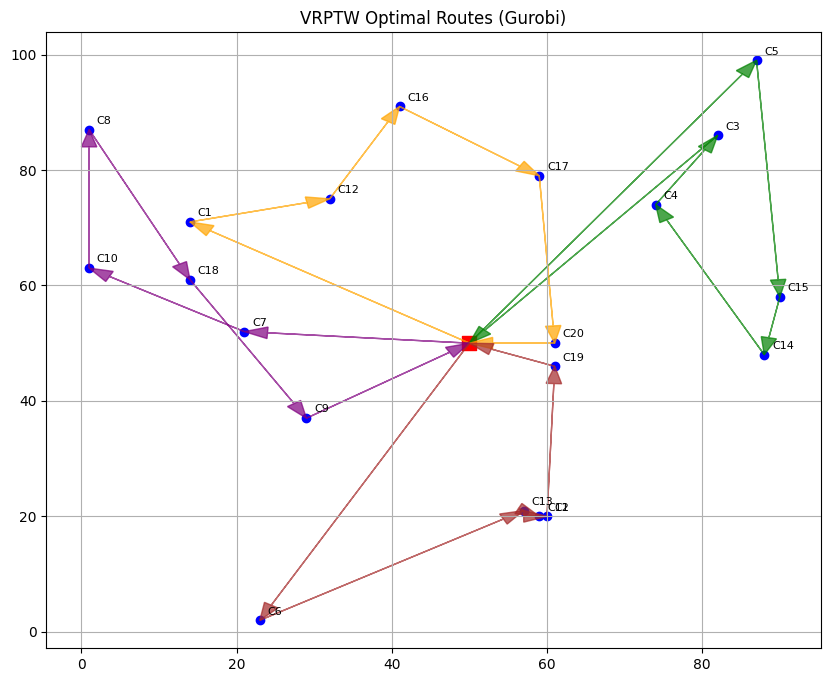

In [8]:
# Visualization of the optimized result

def plot_routes(data, model):
    plt.figure(figsize=(10, 8))
    locs = data['locations']
    
    # 1. Plot Depot and Customers
    plt.scatter(locs[0][0], locs[0][1], c='red', marker='s', s=100, label='Depot')
    for i in range(1, data['num_locations']):
        plt.scatter(locs[i][0], locs[i][1], c='blue')
        plt.text(locs[i][0]+1, locs[i][1]+1, f"C{i}", fontsize=8)

    # 2. Plot Routes (Safe Access)
    colors = ['green', 'orange', 'purple', 'brown', 'black', 'gray']
    for v in range(data['num_vehicles']):
        for i in range(data['num_locations']):
            for j in range(data['num_locations']):
                if i == j: continue # Skip self-loops
                
                # Check if the variable exists and has a value
                var = model.x[i,j,v]
                if var.stale is False and var.value is not None:
                    if var.value > 0.5:
                        plt.arrow(locs[i][0], locs[i][1], 
                                  locs[j][0]-locs[i][0], locs[j][1]-locs[i][1], 
                                  color=colors[v % len(colors)], head_width=2, 
                                  length_includes_head=True, alpha=0.7)

    plt.title("VRPTW Optimal Routes (Gurobi)")
    plt.grid(True)
    plt.show()

plot_routes(data, model_gurobi)

## Problem 3

### This is a custome B&B solver for routing MILP problem to benchmark against TSPLIB/CVRPLIB dataset

In [9]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import numpy as np
from scipy.optimize import linprog
import heapq
import time
import os

# ==========================================
# 1. TSPLIB/CVRPLIB PARSER
# ==========================================
class ProblemParser:
    """Parses .tsp and .vrp files into distance matrices and demands."""
    @staticmethod
    def parse_file(filepath):
        with open(filepath, 'r') as f:
            lines = f.readlines()
        
        data = {'name': '', 'type': '', 'dimension': 0, 'capacity': 0, 'coords': [], 'demands': [], 'weights': []}
        section = None
        
        for line in lines:
            line = line.strip()
            if not line: continue
            
            if ':' in line and section is None:
                key, val = line.split(':', 1)
                key = key.strip().upper()
                if 'NAME' in key: data['name'] = val.strip()
                elif 'TYPE' in key: data['type'] = val.strip()
                elif 'DIMENSION' in key: data['dimension'] = int(val.strip())
                elif 'CAPACITY' in key: data['capacity'] = int(val.strip())
                continue

            if line == 'NODE_COORD_SECTION': section = 'coords'; continue
            if line == 'DEMAND_SECTION': section = 'demands'; continue
            if line == 'EDGE_WEIGHT_SECTION': section = 'weights'; continue
            if line in ['DEPOT_SECTION', 'EOF']: section = None; continue

            parts = line.split()
            if section == 'coords':
                data['coords'].append((float(parts[1]), float(parts[2])))
            elif section == 'demands':
                data['demands'].append(int(parts[1]))
            elif section == 'weights':
                data['weights'].extend([int(p) for p in parts])

        return data

    @staticmethod
    def build_matrix(data):
        dim = data['dimension']
        matrix = np.zeros((dim, dim))
        
        if data['coords']:
            coords = np.array(data['coords'])
            for i in range(dim):
                for j in range(dim):
                    matrix[i][j] = np.linalg.norm(coords[i] - coords[j])
        elif data['weights']:
            # Handles Lower-Row/Full-Matrix inflation
            idx = 0
            for i in range(dim):
                for j in range(i + 1): # Common Lower-Diagonal format
                    if idx < len(data['weights']):
                        val = data['weights'][idx]
                        matrix[i][j] = matrix[j][i] = val
                        idx += 1
        return matrix

# ==========================================
# 2. GUROBI GROUND TRUTH GENERATOR
# ==========================================
def get_gurobi_ground_truth(matrix):
    """
    Solves the TSP using Gurobi to find the absolute ground truth.
    Uses the exact same MTZ formulation for a fair comparison.
    """
    n = len(matrix)
    
    # Create Gurobi environment and model
    # (Suppressing console output for cleaner loop printing)
    env = gp.Env(empty=True)
    env.setParam('OutputFlag', 0) 
    env.start()
    model = gp.Model("TSP_Ground_Truth", env=env)

    # Variables
    # x[i,j] = 1 if edge from i to j is used
    x = model.addVars(n, n, vtype=GRB.BINARY, name="x")
    # u[i] = sequence position of node i for MTZ subtour elimination
    u = model.addVars(n, vtype=GRB.CONTINUOUS, name="u")

    # Objective: Minimize total distance
    model.setObjective(gp.quicksum(matrix[i][j] * x[i, j] for i in range(n) for j in range(n)), GRB.MINIMIZE)

    # Constraints: Leave each city exactly once
    for i in range(n):
        model.addConstr(gp.quicksum(x[i, j] for j in range(n) if i != j) == 1, name=f"out_{i}")

    # Constraints: Enter each city exactly once
    for j in range(n):
        model.addConstr(gp.quicksum(x[i, j] for i in range(n) if i != j) == 1, name=f"in_{j}")

    # Constraints: MTZ Subtour Elimination
    for i in range(1, n):
        for j in range(1, n):
            if i != j:
                model.addConstr(u[i] - u[j] + n * x[i, j] <= n - 1, name=f"mtz_{i}_{j}")

    # Prevent self-loops explicitly
    for i in range(n):
        model.addConstr(x[i, i] == 0)

    # Solve
    model.optimize()

    if model.status == GRB.OPTIMAL:
        return model.ObjVal
    else:
        return None

# ==========================================
# 3. GUROBI RUNNER: GENERATE THE BENCHMARK TABLE
# ==========================================
# Assuming you already have the `ProblemParser` from the previous cell loaded
filename = 'gr17.tsp'
data = ProblemParser.parse_file(filename)
full_matrix = ProblemParser.build_matrix(data)

# Test subsets to build your report table
subsets_to_test = [5, 6, 8, 10, 12, 14, 15, 17]

print("--- Generating Gurobi Ground Truths ---")
print(f"{'N-Cities':<10} | {'Optimal Objective (Ground Truth)'}")
print("-" * 45)

for n in subsets_to_test:
    sub_matrix = full_matrix[:n, :n]
    optimal_val = get_gurobi_ground_truth(sub_matrix)
    print(f"{n:<10} | {optimal_val}")

# ==========================================
# 4. THE CORE MILP SOLVER (BRANCH & BOUND)
# ==========================================
class CustomMILPSolver:
    def __init__(self, c, A, b, int_indices):
        self.c, self.A, self.b = c, A, b
        self.int_indices = int_indices
        self.best_obj = np.inf
        self.best_sol = None
        self.nodes = 0

    def solve(self, timeout=60):
        start_t = time.time()
        # Initialize Bounds (Binary for x_ij, Non-negative for u_i)
        init_b = [(0, 1) if i in self.int_indices else (0, None) for i in range(len(self.c))]
        
        # Priority Queue for Best-Bound Search
        queue = []
        res = linprog(self.c, A_ub=self.A, b_ub=self.b, bounds=init_b, method='highs')
        if res.success:
            heapq.heappush(queue, (res.fun, 0, init_b))

        while queue and (time.time() - start_t) < timeout:
            lp_obj, _, curr_b = heapq.heappop(queue)
            self.nodes += 1
            if lp_obj >= self.best_obj: continue

            # Re-solve to get solution values
            sol = linprog(self.c, A_ub=self.A, b_ub=self.b, bounds=curr_b, method='highs').x
            
            # Find first fractional integer variable
            branch_idx = next((i for i in self.int_indices if 0.01 < (sol[i] % 1) < 0.99), None)

            if branch_idx is None: # Found Integer Feasible
                if lp_obj < self.best_obj:
                    self.best_obj, self.best_sol = lp_obj, sol
            else: # Branching
                val = sol[branch_idx]
                for new_v, is_upper in [(np.floor(val), True), (np.ceil(val), False)]:
                    new_b = list(curr_b)
                    low, high = new_b[branch_idx]
                    if is_upper: new_b[branch_idx] = (low, min(high if high is not None else np.inf, new_v))
                    else: new_b[branch_idx] = (max(low, new_v), high)
                    
                    res = linprog(self.c, A_ub=self.A, b_ub=self.b, bounds=new_b, method='highs')
                    if res.success:
                        heapq.heappush(queue, (res.fun, self.nodes, tuple(new_b)))

# ==========================================
# 5. MILP BUILDER (MTZ TSP Formulation)
# ==========================================
def build_milp_from_matrix(dist_matrix):
    n = len(dist_matrix)
    num_vars = n*n + n # x_ij + u_i
    c = np.zeros(num_vars)
    for i in range(n):
        for j in range(n): c[i*n + j] = dist_matrix[i][j]

    A, b = [], []
    # Degree Constraints
    for i in range(n):
        row_out, row_in = np.zeros(num_vars), np.zeros(num_vars)
        for j in range(n):
            if i != j: 
                row_out[i*n + j] = 1
                row_in[j*n + i] = 1
        A.extend([row_out, -row_out, row_in, -row_in])
        b.extend([1, -1, 1, -1])

    # MTZ Subtour Elimination
    for i in range(1, n):
        for j in range(1, n):
            if i != j:
                row = np.zeros(num_vars)
                row[n*n+i], row[n*n+j], row[i*n+j] = 1, -1, n
                A.append(row); b.append(n-1)

    return c, np.array(A), np.array(b), list(range(n*n))

# ==========================================
# 6. REPRODUCIBLE CUSTOM B&B BENCHMARK RUNNER
# ==========================================
def run_benchmark(filename, ground_truth, subset_n=None):
    if not os.path.exists(filename):
        print(f"File {filename} not found. Please place it in the same directory.")
        return

    print(f"\n--- Benchmarking {filename} ---")
    data = ProblemParser.parse_file(filename)
    matrix = ProblemParser.build_matrix(data)
    
    # --- MODIFICATION: SUB-SAMPLING LOGIC ---
    if subset_n is not None:
        print(f"Applying dimensionality reduction: Sub-sampling to first {subset_n} cities.")
        matrix = matrix[:subset_n, :subset_n]
    # ----------------------------------------

    c, A, b, int_idx = build_milp_from_matrix(matrix)
    
    solver = CustomMILPSolver(c, A, b, int_idx)
    start = time.time()
    solver.solve(timeout=60)
    end = time.time()

    print(f"Target Optimal: {ground_truth}")
    print(f"Solver Result:  {solver.best_obj:.2f}")
    if solver.best_obj != np.inf:
        print(f"Gap:            {((solver.best_obj - ground_truth)/ground_truth)*100:.2f}%")
    else:
        print("Gap:            N/A (Timeout/Infeasible)")
    print(f"Nodes Explored: {solver.nodes}")
    print(f"Runtime:        {end-start:.2f}s\n")

# To run the full problem
# run_benchmark('gr17.tsp', 2085)

--- Generating Gurobi Ground Truths ---
N-Cities   | Optimal Objective (Ground Truth)
---------------------------------------------
5          | 1348.0
6          | 1352.0
8          | 1346.0
10         | 1637.0
12         | 1799.0
14         | 1872.0
15         | 1908.0
17         | 2085.0


In [10]:
# To run the benchmark on N=6, 8 or 10 subset
run_benchmark('gr17.tsp', ground_truth=1348, subset_n=5)
run_benchmark('gr17.tsp', ground_truth=1352, subset_n=6)
run_benchmark('gr17.tsp', ground_truth=1346, subset_n=8)
run_benchmark('gr17.tsp', ground_truth=1637, subset_n=10)
run_benchmark('gr17.tsp', ground_truth=1799, subset_n=12)
run_benchmark('gr17.tsp', ground_truth=1872, subset_n=14)
run_benchmark('gr17.tsp', ground_truth=1908, subset_n=15)
run_benchmark('gr17.tsp', ground_truth=2085, subset_n=17)


--- Benchmarking gr17.tsp ---
Applying dimensionality reduction: Sub-sampling to first 5 cities.
Target Optimal: 1348
Solver Result:  1348.00
Gap:            0.00%
Nodes Explored: 31
Runtime:        0.19s


--- Benchmarking gr17.tsp ---
Applying dimensionality reduction: Sub-sampling to first 6 cities.
Target Optimal: 1352
Solver Result:  1352.00
Gap:            0.00%
Nodes Explored: 69
Runtime:        0.34s


--- Benchmarking gr17.tsp ---
Applying dimensionality reduction: Sub-sampling to first 8 cities.
Target Optimal: 1346
Solver Result:  1346.00
Gap:            0.00%
Nodes Explored: 167
Runtime:        1.06s


--- Benchmarking gr17.tsp ---
Applying dimensionality reduction: Sub-sampling to first 10 cities.
Target Optimal: 1637
Solver Result:  1637.00
Gap:            0.00%
Nodes Explored: 341
Runtime:        3.24s


--- Benchmarking gr17.tsp ---
Applying dimensionality reduction: Sub-sampling to first 12 cities.
Target Optimal: 1799
Solver Result:  inf
Gap:            N/A (Timeout/

## Problem 4

### This is a custom B&B solver for MILP covering the pen-paper problem "just for fun".

In [11]:
import numpy as np
from scipy.optimize import linprog
import heapq

class MILPNode:
    """Represents a single node in the Branch-and-Bound search tree."""
    def __init__(self, x_bounds, y_bounds, level, parent_obj):
        self.x_bounds = x_bounds
        self.y_bounds = y_bounds
        self.level = level
        self.parent_obj = parent_obj
        self.lp_solution = None
        self.lp_obj = None
        self.is_feasible = False

    def solve_relaxation(self, objective, A, b):
        """Solves the LP relaxation for this node's specific bounds."""
        res = linprog(c=objective, A_ub=A, b_ub=b, 
                      bounds=[self.x_bounds, self.y_bounds], method='highs')
        if res.success:
            self.is_feasible = True
            self.lp_obj = -res.fun # Convert back to Maximize
            self.lp_solution = res.x
        return self.is_feasible

    def __lt__(self, other):
        # Priority Queue: Explore highest LP objective first (Best-Bound)
        return self.lp_obj > other.lp_obj

class CustomMILPSolver:
    def __init__(self, objective, A, b):
        self.objective = objective # coefficients for [x, y]
        self.A = A
        self.b = b
        self.best_integer_obj = -np.inf
        self.best_integer_solution = None
        self.nodes_explored = 0
        self.tree = []

    def solve(self):
        # 1. Start with the Root Node (No integer constraints yet)
        root = MILPNode((0, None), (0, None), level=0, parent_obj=np.inf)
        if not root.solve_relaxation(self.objective, self.A, self.b):
            print("Initial LP is Infeasible!")
            return

        heapq.heappush(self.tree, root)
        
        print(f"{'Node':<5} | {'Level':<5} | {'LP Obj':<10} | {'Status':<15} | {'Best Int'}")
        print("-" * 60)

        while self.tree:
            node = heapq.heappop(self.tree)
            self.nodes_explored += 1
            
            # --- PRUNING LOGIC ---
            if node.lp_obj <= self.best_integer_obj:
                print(f"{self.nodes_explored:<5} | {node.level:<5} | {node.lp_obj:<10.2f} | Pruned by Bound | {self.best_integer_obj}")
                continue

            x, y = node.lp_solution
            
            # --- INTEGRALITY CHECK ---
            if self.is_integer(x) and self.is_integer(y):
                if node.lp_obj > self.best_integer_obj:
                    self.best_integer_obj = node.lp_obj
                    self.best_integer_solution = (round(x), round(y))
                print(f"{self.nodes_explored:<5} | {node.level:<5} | {node.lp_obj:<10.2f} | INTEGER FOUND  | {self.best_integer_obj}")
            else:
                # --- BRANCHING LOGIC ---
                print(f"{self.nodes_explored:<5} | {node.level:<5} | {node.lp_obj:<10.2f} | Branching...   | {self.best_integer_obj}")
                
                # Branch on the most fractional variable
                branch_var_idx = 0 if abs(x - round(x)) > abs(y - round(y)) else 1
                val = node.lp_solution[branch_var_idx]
                
                # Create Left Child (var <= floor(val))
                self.create_child(node, branch_var_idx, (0, np.floor(val)), "left")
                # Create Right Child (var >= ceil(val))
                self.create_child(node, branch_var_idx, (np.ceil(val), None), "right")

    def create_child(self, parent, var_idx, new_bound, side):
        xb = list(parent.x_bounds)
        yb = list(parent.y_bounds)
        if var_idx == 0:
            xb = (max(xb[0], new_bound[0]), min(xb[1] or np.inf, new_bound[1] or np.inf))
        else:
            yb = (max(yb[0], new_bound[0]), min(yb[1] or np.inf, new_bound[1] or np.inf))
            
        child = MILPNode(tuple(xb), tuple(yb), parent.level + 1, parent.lp_obj)
        if child.solve_relaxation(self.objective, self.A, self.b):
            heapq.heappush(self.tree, child)

    def is_integer(self, val):
        return abs(val - round(val)) < 1e-6

# --- DEMO PROBLEM STATEMENT ---
# Maximize Z = 5x + 8y
# Subject to:
# 1x + 1y <= 6
# 5x + 9y <= 45
# x, y are non-negative integers
obj = [-5, -8] # Negative for maximization
A_ub = [[1, 1], [5, 9]]
b_ub = [6, 45]

solver = CustomMILPSolver(obj, A_ub, b_ub)
solver.solve()
print(f"\nFinal Solution: {solver.best_integer_solution} with Obj: {solver.best_integer_obj}")

Node  | Level | LP Obj     | Status          | Best Int
------------------------------------------------------------
1     | 0     | 41.25      | Branching...   | -inf
2     | 1     | 41.00      | Branching...   | -inf
3     | 2     | 40.56      | Branching...   | -inf
4     | 3     | 40.00      | INTEGER FOUND  | 40.0
5     | 1     | 39.00      | Pruned by Bound | 40.0
6     | 3     | 37.00      | Pruned by Bound | 40.0

Final Solution: (0, 5) with Obj: 40.0
